# California CASTNET — Multi-Pollutant Feature Engineering

**Builds on:** `ca_data_extraction_combined.ipynb`  
**Outputs to:** `model_preparation.ipynb`

### What this notebook does
| Step | Action |
|------|--------|
| 1 | Load all 6 CA processed tables from `processed_data/california/` |
| 2 | Discover all sites dynamically from `ca_ozone.csv` — no hardcoded site list |
| 3 | `SiteHourlyFeatures` — left-joins each ancillary table with no data leakage |
| 4 | Temporal features (cyclical encoding, season, fire season, marine layer) |
| 5 | Ozone lag / rolling / differencing / velocity features |
| 6 | Multi-pollutant features: NO, NO₂, NOy, HNO₃, SO₂, CO, TEMP_2M |
| 6b | **Step 3:** CA-specific: `high_pm25`, `is_coastal_site`, `hour_x_coastal`, `ozone_annual_site_mean` |
| 7 | Weekly chemistry forward-fill: DRYCHEM (SO4, NO3, NH4) + WET CONC (pH, precip) |
| 8 | PurpleAir PM₂.₅ wildfire proxy features |
| 9 | California-specific features: 8-hr rolling max, NAAQS exceedance flag, precursor ratios |
| 10 | Static site features: elevation band, coast distance, terrain class |
| 11 | Per-site processing loop → concatenate → Parquet output |
| 12 | Feature audit, correlation report, importance pre-screen |

**Works for any number of CA sites** — site list and metadata are derived
dynamically from the data files produced by the extraction notebook.


## Section 1: Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import os
import gc
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import dask

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

dask.config.set({'dataframe.shuffle.method': 'tasks'})

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"dask    : {dask.__version__}")


pandas  : 2.2.2
numpy   : 1.26.4
dask    : 2026.1.2


## Section 2: Configuration

In [2]:
DATA_DIR        = r"C:\MATH699P\Data"
CA_DIR          = os.path.join(DATA_DIR, 'processed_data', 'california')
OUTPUT_DIR      = os.path.join(DATA_DIR, 'processed_data', 'california', 'features_parquet')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Fire exposure path (produced by ca_fire_exposure_processing.ipynb) ──────
# Single definition — referenced by load_ca_table() below.
# Change this one variable if the dashboard_data directory moves.
DASH_DIR        = os.path.join(DATA_DIR, 'dashboard_data')
FIRE_DAILY_PATH = os.path.join(DASH_DIR, 'site_fire_exposure_daily.parquet')

print(f"Input  : {CA_DIR}")
print(f"Output : {OUTPUT_DIR}")

Input  : C:\MATH699P\Data\processed_data\california
Output : C:\MATH699P\Data\processed_data\california\features_parquet


In [3]:
# ── Feature engineering config ────────────────────────────────────────────────
FE_CONFIG = {
    # Ozone lags (hours)
    'ozone_lags'          : [1, 2, 3, 6, 12, 24, 48, 168],
    # Rolling windows (hours)
    'rolling_windows'     : [3, 6, 12, 24, 168],
    # Differencing periods (hours)
    'diff_periods'        : [1, 24, 168],
    # 8-hr rolling max window (EPA NAAQS standard)
    'naaqs_window'        : 8,
    # NAAQS O3 standard (ppb)
    'naaqs_threshold'     : 70.0,
    # Marine layer threshold: coast distance (km) for MARINE_CODE (broad)
    'marine_coast_km'     : 100.0,
    # ── Step 3 additions ──────────────────────────────────────────────────────
    # Coastal threshold for marine boundary layer interaction feature (tight)
    # Sites < 50 km from coast experience direct marine layer intrusion daily
    'coastal_km'          : 50.0,
    # Wildfire season months (California)
    'fire_season_months'  : [6, 7, 8, 9, 10],
    # 24-hr rolling PM2.5 threshold for is_wildfire_smoke flag (µg/m³)
    'wildfire_pm25'       : 35.0,
    # Instantaneous PM2.5 threshold for high_pm25 flag (µg/m³)
    # Separate from wildfire_pm25 — flags individual elevated hours, not sustained events
    'high_pm25_threshold' : 35.0,
    # Gas lag features (hours)
    'gas_lags'            : [1, 3, 6, 24],
    'gas_rolling'         : [3, 6, 24],
    # ── Trend feature ─────────────────────────────────────────────────────────
    # Training cutoff year — ozone_annual_site_mean is computed using ONLY
    # years ≤ this value to prevent leakage into validation / test sets.
    'train_cutoff_year'   : 2018,
}

print("FE_CONFIG:")
for k, v in FE_CONFIG.items():
    print(f"  {k:<28s} : {v}")


FE_CONFIG:
  ozone_lags                   : [1, 2, 3, 6, 12, 24, 48, 168]
  rolling_windows              : [3, 6, 12, 24, 168]
  diff_periods                 : [1, 24, 168]
  naaqs_window                 : 8
  naaqs_threshold              : 70.0
  marine_coast_km              : 100.0
  coastal_km                   : 50.0
  fire_season_months           : [6, 7, 8, 9, 10]
  wildfire_pm25                : 35.0
  high_pm25_threshold          : 35.0
  gas_lags                     : [1, 3, 6, 24]
  gas_rolling                  : [3, 6, 24]
  train_cutoff_year            : 2018


## Section 3: Load All California Data Sources

In [4]:
def load_ca_table(name, parse_dates=None, required=True, parquet=False, path=None):
    """
    Load a processed CA table from CA_DIR.

    Parameters
    ----------
    name        : str   — filename without extension
    parse_dates : list  — column names to parse as datetime (CSV only)
    required    : bool  — raise on missing if True, else return empty DataFrame
    parquet     : bool  — read as Parquet instead of CSV (default False)
    path        : str   — override full path (use for files outside CA_DIR)
    """
    ext = 'parquet' if parquet else 'csv'
    if path is None:
        path = os.path.join(CA_DIR, f'{name}.{ext}')

    if not os.path.exists(path):
        if required:
            raise FileNotFoundError(f"Required file missing: {path}")
        print(f"  ⚠  {name}.{ext} not found — returning empty DataFrame")
        return pd.DataFrame()

    try:
        if parquet:
            df = pd.read_parquet(path)
        else:
            df = pd.read_csv(path, low_memory=False,
                             parse_dates=parse_dates if parse_dates else False)
    except Exception as e:
        if required:
            raise
        print(f"  ⚠  Failed to read {name}.{ext}: {e} — returning empty DataFrame")
        return pd.DataFrame()

    if parse_dates and not parquet:
        for col in parse_dates:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')
    elif parquet and parse_dates:
        for col in parse_dates:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"  ✓  {name:<35s} {len(df):>10,} rows  ×  {len(df.columns):>3d} cols")
    return df

print("Loading California data sources...")
print("-" * 65)
df_ozone     = load_ca_table('ca_ozone',               parse_dates=['DATE_TIME'])
df_site      = load_ca_table('ca_site_static_features', required=False)
df_gas       = load_ca_table('ca_hourly_gas',           parse_dates=['DATE_TIME'], required=False)
df_drychem   = load_ca_table('ca_drychem',              parse_dates=['DATEON', 'DATEOFF'], required=False)
df_wet       = load_ca_table('ca_wet_conc',             parse_dates=['DATEON', 'DATEOFF'], required=False)
df_purpleair = load_ca_table('ca_purpleair',            parse_dates=['DATE_TIME'], required=False)

# ── Optional: FRAP fire exposure (daily) for wildfire-aware features ──────────
# Produced by ca_fire_exposure_processing.ipynb and saved to DASH_DIR.
# Path is defined once in the config cell (FIRE_DAILY_PATH) — change it there.
df_fire_daily = load_ca_table(
    'site_fire_exposure_daily',
    parse_dates=['date'],
    required=False,
    parquet=True,
    path=FIRE_DAILY_PATH,
)
if df_fire_daily.empty:
    print(f"  ⚠  FIRE_DAILY_PATH={FIRE_DAILY_PATH!r}")
    print("     → fire_* features will be zeros. Run ca_fire_exposure_processing.ipynb first.")


print(f"\nOzone date range : {df_ozone['DATE_TIME'].min()} → {df_ozone['DATE_TIME'].max()}")
print(f"Sites in ozone   : {sorted(df_ozone['SITE_ID'].unique())}")
print(f"Site count       : {df_ozone['SITE_ID'].nunique()}")

# ── Build CA_SITE_META dynamically from df_site ───────────────────────────────
# This replaces the old hardcoded 6-site dict and automatically picks up any
# site present in ca_site_static_features.csv, including the 4 Southern CA sites.
if not df_site.empty:
    _meta_cols = [c for c in ['COAST_DIST_KM', 'ELEVATION_M', 'MARINE_INFLUENCE',
                               'TERRAIN_CLASS', 'LAND_USE_CLASS', 'REGION',
                               'DISPLAY_NAME', 'LAT', 'LON'] if c in df_site.columns]
    CA_SITE_META = (
        df_site[['SITE_ID'] + _meta_cols]
        .drop_duplicates('SITE_ID')
        .set_index('SITE_ID')
        .to_dict('index')
    )
    print(f"\nCA_SITE_META built from df_site: {len(CA_SITE_META)} sites")
    print(f"  Sites: {sorted(CA_SITE_META.keys())}")
else:
    # Fallback: derive from ozone spine with defaults — no site file present
    CA_SITE_META = {sid: {'COAST_DIST_KM': 0.0, 'ELEVATION_M': 0,
                          'MARINE_INFLUENCE': 'INLAND'}
                    for sid in df_ozone['SITE_ID'].unique()}
    print(f"\n⚠  df_site empty — CA_SITE_META built with defaults for {len(CA_SITE_META)} sites")

Loading California data sources...
-----------------------------------------------------------------
  ✓  ca_ozone                             1,960,605 rows  ×   12 cols
  ✓  ca_site_static_features                     15 rows  ×   10 cols
  ⚠  Failed to read ca_hourly_gas.csv: No columns to parse from file — returning empty DataFrame
  ✓  ca_drychem                              12,193 rows  ×   12 cols
  ⚠  Failed to read ca_wet_conc.csv: No columns to parse from file — returning empty DataFrame
  ✓  ca_purpleair                            13,824 rows  ×    4 cols
  ✓  site_fire_exposure_daily               329,757 rows  ×    7 cols

Ozone date range : 1990-01-01 00:00:00 → 2025-05-31 23:00:00
Sites in ozone   : ['CAN407', 'CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 'SEK402', 'SEK430', 'SND152', 'YOS204', 'YOS404']
Site count       : 12

CA_SITE_META built from df_site: 15 sites
  Sites: ['ABF404', 'CAN407', 'CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 

## Section 4: Ozone Spine Preprocessing & Downcast

In [5]:
print("Preprocessing ozone spine...")
print("-" * 60)

# Drop metadata columns not needed for modelling
drop_cols = ['OZONE_F', 'UNITS', 'EXPECTED_VALUE', 'CALIBRATION_VALUE',
             'CALIBRATION_TYPE', 'UPDATE_DATE', 'QA_CODE']
df_ozone = df_ozone.drop(columns=[c for c in drop_cols if c in df_ozone.columns])

# Ensure DATE_TIME is timezone-naive
df_ozone['DATE_TIME'] = df_ozone['DATE_TIME'].dt.tz_localize(None) \
    if df_ozone['DATE_TIME'].dt.tz is not None else df_ozone['DATE_TIME']

# Downcast ozone spine + all merge sources before the site loop
# Applying here once — before SiteHourlyFeatures runs — halves peak memory.
def _downcast_df(df):
    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes('int64').columns:
        df[col] = df[col].astype('int32')
    return df

df_ozone     = _downcast_df(df_ozone)
df_gas       = _downcast_df(df_gas)       if not df_gas.empty       else df_gas
df_drychem   = _downcast_df(df_drychem)   if not df_drychem.empty   else df_drychem
df_wet       = _downcast_df(df_wet)       if not df_wet.empty       else df_wet
df_purpleair = _downcast_df(df_purpleair) if not df_purpleair.empty else df_purpleair

# Sort — critical for all subsequent lag/rolling operations
df_ozone = df_ozone.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)

mem_mb = df_ozone.memory_usage(deep=True).sum() / (1024**2)
print(f"Ozone spine  : {len(df_ozone):,} rows × {len(df_ozone.columns)} cols")
print(f"Memory       : {mem_mb:.1f} MB")
print(f"Sites        : {df_ozone['SITE_ID'].nunique()}")
print(f"Date range   : {df_ozone['DATE_TIME'].min()} → {df_ozone['DATE_TIME'].max()}")

Preprocessing ozone spine...
------------------------------------------------------------
Ozone spine  : 1,960,605 rows × 5 cols
Memory       : 140.2 MB
Sites        : 12
Date range   : 1990-01-01 00:00:00 → 2025-05-31 23:00:00


In [6]:
# ── Pre-sort weekly tables + per-site merge onto ozone spine ─────────────────
#
# SiteHourlyFeatures._merge_drychem / _merge_wet_conc previously sorted each
# table inside a Python for-loop (once per site, 10× redundant). Here we:
#   1. Sort and deduplicate both weekly tables ONCE globally
#   2. Slice the pre-sorted right frame per site (O(1) boolean index)
#   3. Call merge_asof on each site slice — no re-sort cost per iteration
#
# pd.merge_asof(by='SITE_ID') was attempted but imposes undocumented internal
# sort constraints that fail with interleaved multi-site timestamps. The
# explicit per-site loop with pre-sorted slices is equivalent in performance
# (pandas does the same grouping internally) and provably correct.

def _pre_merge_weekly(spine, df_weekly, value_cols, prefix, date_col='DATEOFF'):
    """
    Merge a weekly table onto an hourly spine for all sites at once.

    Both frames are sorted once before entering the site loop. Each per-site
    slice is already sorted, so merge_asof needs no additional sort work.

    Parameters
    ----------
    spine      : hourly ozone frame, sorted by [SITE_ID, DATE_TIME]
    df_weekly  : weekly table with SITE_ID + date_col + value_cols
    prefix     : column prefix applied to merged value columns, e.g. 'DC_'
    date_col   : name of the date column in df_weekly (default 'DATEOFF')
    """
    avail = [c for c in value_cols if c in df_weekly.columns]
    if not avail or date_col not in df_weekly.columns:
        return spine

    # Pre-sort weekly table ONCE — slices inherits this order per site
    right = (
        df_weekly[['SITE_ID', date_col] + avail]
        .dropna(subset=[date_col])
        .drop_duplicates(['SITE_ID', date_col], keep='last')
        .rename(columns={date_col: 'DATE_TIME',
                         **{c: f'{prefix}{c}' for c in avail}})
        .sort_values(['SITE_ID', 'DATE_TIME'])
        .reset_index(drop=True)
    )
    for col in right.select_dtypes('float64').columns:
        right[col] = right[col].astype('float32')

    # Per-site merge using pre-sorted slices (no re-sort cost per iteration)
    parts = []
    for sid, left_grp in spine.groupby('SITE_ID', sort=False):
        right_grp = right.loc[right['SITE_ID'] == sid].drop(columns=['SITE_ID'])
        if right_grp.empty:
            parts.append(left_grp)
            continue
        parts.append(pd.merge_asof(
            left_grp,          # already sorted by DATE_TIME within this site
            right_grp,         # already sorted by DATE_TIME within this site
            on='DATE_TIME',
            direction='backward',   # no look-ahead: only completed samples
        ))

    return pd.concat(parts).sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)


# Sort spine by [SITE_ID, DATE_TIME] once — groupby below preserves this order
df_ozone = df_ozone.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)

DRYCHEM_COLS = ['TSO4', 'TNO3', 'TNH4', 'CA', 'MG', 'NA', 'K', 'CL', 'SO2', 'HNO3']
WET_COLS     = ['SO4', 'NO3', 'NH4', 'PH', 'COND', 'SUB_PPT', 'CA', 'CL']

df_ozone = _pre_merge_weekly(df_ozone, df_drychem, DRYCHEM_COLS, 'DC_')
df_ozone = _pre_merge_weekly(df_ozone, df_wet,     WET_COLS,     'WET_')

_dc_cols_merged  = [c for c in df_ozone.columns if c.startswith('DC_')]
_wet_cols_merged = [c for c in df_ozone.columns if c.startswith('WET_')]
print(f"Pre-merged weekly tables onto ozone spine:")
print(f"  DC_*  : {_dc_cols_merged}")
print(f"  WET_* : {_wet_cols_merged}")
print(f"  Spine : {len(df_ozone):,} rows × {df_ozone.shape[1]} cols")

Pre-merged weekly tables onto ozone spine:
  DC_*  : ['DC_TSO4', 'DC_TNO3', 'DC_TNH4', 'DC_CA', 'DC_MG', 'DC_NA', 'DC_K', 'DC_CL']
  WET_* : []
  Spine : 1,960,605 rows × 13 cols


## Section 5: `SiteHourlyFeatures` — Multi-Source Merge Engine

This class is the core of the multi-pollutant integration. It takes the hourly
ozone spine for a **single site** and safely left-joins every ancillary table.

### Merge strategy to prevent data leakage
| Source | Frequency | Join method |
|--------|-----------|-------------|
| `ca_hourly_gas` | Hourly | Direct left-join on `SITE_ID + DATE_TIME` |
| `ca_drychem` | Weekly | `merge_asof` on `DATEOFF` → forward-fill, **never look-ahead** |
| `ca_wet_conc` | Weekly | `merge_asof` on `DATEOFF` → forward-fill, **never look-ahead** |
| `ca_purpleair` | Hourly | Direct left-join on `SITE_ID + DATE_TIME` |
| `ca_site_static_features` | Static | Simple scalar assignment by `SITE_ID` |

`merge_asof` with `direction='backward'` ensures the most recent *completed*
weekly sample is used at each hourly timestamp — the sample whose collection
window ended **before** the current hour.


In [7]:
class SiteHourlyFeatures:
    """
    Builds the complete multi-pollutant feature DataFrame for one CA site.

    Parameters
    ----------
    site_id     : str
    df_ozone    : hourly ozone spine (all sites, pre-sorted)
    df_gas      : hourly gas wide-format (all sites)
    df_drychem  : weekly drychem (all sites)
    df_wet      : weekly wet concentration (all sites)
    df_purpleair: hourly PurpleAir PM2.5 (all sites)
    df_site     : static site metadata (all sites)
    df_fire_daily: daily FRAP fire exposure (all sites; produced by ca_fire_exposure_processing.ipynb)
    config      : FE_CONFIG dict
    """

    def __init__(self, site_id, df_ozone, df_gas, df_drychem,
                 df_wet, df_purpleair, df_fire_daily, df_site, config):
        self.sid      = site_id
        self.config   = config
        self.spine    = df_ozone[df_ozone['SITE_ID'] == site_id].copy()
        self.gas      = df_gas[df_gas['SITE_ID'] == site_id].copy() if not df_gas.empty else pd.DataFrame()
        self.drychem  = df_drychem[df_drychem['SITE_ID'] == site_id].copy() if not df_drychem.empty else pd.DataFrame()
        self.wet      = df_wet[df_wet['SITE_ID'] == site_id].copy() if not df_wet.empty else pd.DataFrame()
        self.pa       = df_purpleair[df_purpleair['SITE_ID'] == site_id].copy() if not df_purpleair.empty else pd.DataFrame()
        self.fire     = df_fire_daily[df_fire_daily['SITE_ID'] == site_id].copy() if (isinstance(df_fire_daily, pd.DataFrame) and not df_fire_daily.empty and 'SITE_ID' in df_fire_daily.columns) else pd.DataFrame()
        self.site_row = df_site[df_site['SITE_ID'] == site_id].iloc[0].to_dict() if (
            not df_site.empty and site_id in df_site['SITE_ID'].values) else {}

    # ── 5a: Static site features ────────────────────────────────────────────
    def _add_static_features(self, df):
        """Broadcast static scalars from site metadata onto every row."""
        static_map = {
            'ELEVATION_M'      : ('float32', 0.0),
            'COAST_DIST_KM'    : ('float32', 0.0),
            'LAT'              : ('float32', 0.0),
            'LON'              : ('float32', 0.0),
        }
        for col, (dtype, default) in static_map.items():
            val = self.site_row.get(col, default)
            df[col] = np.float32(val) if pd.notna(val) else np.float32(default)

        # Categorical → integer encoding
        marine = self.site_row.get('MARINE_INFLUENCE', 'INLAND')
        df['MARINE_CODE'] = np.int8({'COASTAL': 0, 'TRANSITION': 1, 'INLAND': 2}.get(marine, 2))

        terrain = self.site_row.get('TERRAIN_CLASS', 'SLOPED')
        df['TERRAIN_CODE'] = np.int8({'EXPOSED': 0, 'SLOPED': 1, 'COMPLEX': 2}.get(terrain, 1))

        return df

    # ── 5b: Temporal features ───────────────────────────────────────────────
    def _add_temporal_features(self, df):
        dt = df['DATE_TIME']
        df['year']       = dt.dt.year.astype('int16')
        df['month']      = dt.dt.month.astype('int8')
        df['day']        = dt.dt.day.astype('int8')
        df['hour']       = dt.dt.hour.astype('int8')
        df['dayofweek']  = dt.dt.dayofweek.astype('int8')
        df['dayofyear']  = dt.dt.dayofyear.astype('int16')
        df['week']       = dt.dt.isocalendar().week.astype('int8')
        df['quarter']    = dt.dt.quarter.astype('int8')
        df['is_weekend'] = (dt.dt.dayofweek >= 5).astype('int8')

        # Peak photochemical hours (10am – 4pm local) — UV drives O3 formation
        df['is_peak_photo'] = dt.dt.hour.isin(range(10, 17)).astype('int8')
        # Night hours (10pm – 5am) — ozone typically depleted
        df['is_night']      = dt.dt.hour.isin(list(range(0, 6)) + [22, 23]).astype('int8')

        # Cyclical encodings
        df['hour_sin']       = np.sin(2*np.pi*df['hour']/24).astype('float32')
        df['hour_cos']       = np.cos(2*np.pi*df['hour']/24).astype('float32')
        df['month_sin']      = np.sin(2*np.pi*df['month']/12).astype('float32')
        df['month_cos']      = np.cos(2*np.pi*df['month']/12).astype('float32')
        df['dayofyear_sin']  = np.sin(2*np.pi*df['dayofyear']/365.25).astype('float32')
        df['dayofyear_cos']  = np.cos(2*np.pi*df['dayofyear']/365.25).astype('float32')
        df['dayofweek_sin']  = np.sin(2*np.pi*df['dayofweek']/7).astype('float32')
        df['dayofweek_cos']  = np.cos(2*np.pi*df['dayofweek']/7).astype('float32')

        # California-specific flags
        season_map = {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3}
        df['season'] = df['month'].map(season_map).astype('int8')

        df['is_fire_season']    = df['month'].isin(self.config['fire_season_months']).astype('int8')
        df['is_summer_peak']    = df['month'].isin([6,7,8]).astype('int8')  # CA O3 max
        df['is_post_2017']      = (df['year'] >= 2017).astype('int8')       # wildfire era

        # Year trend feature (linear time proxy for emission trend)
        df['year_trend'] = (df['year'] - 1990).astype('float32')

        return df

    # ── 5c: Ozone lag, rolling, differencing ────────────────────────────────
    def _add_ozone_timeseries_features(self, df):
        o = df['OZONE']

        # Lags
        for lag in self.config['ozone_lags']:
            df[f'OZONE_lag_{lag}'] = o.shift(lag).astype('float32')

        # Rolling stats
        for w in self.config['rolling_windows']:
            r = o.rolling(window=w, min_periods=1)
            df[f'OZONE_rmean_{w}'] = r.mean().astype('float32')
            df[f'OZONE_rstd_{w}']  = r.std().fillna(0).astype('float32')
            df[f'OZONE_rmin_{w}']  = r.min().astype('float32')
            df[f'OZONE_rmax_{w}']  = r.max().astype('float32')

        # Differencing
        for p in self.config['diff_periods']:
            df[f'OZONE_diff_{p}'] = o.diff(p).astype('float32')

        # Velocity / acceleration
        df['OZONE_velocity']     = o.diff(1).astype('float32')
        df['OZONE_acceleration'] = df['OZONE_velocity'].diff(1).astype('float32')

        # ── EPA 8-hour rolling maximum (NAAQS standard metric) ────────────
        df['OZONE_8hr_max'] = (
            o.rolling(window=self.config['naaqs_window'], min_periods=4)
             .max()
             .astype('float32')
        )
        # Binary NAAQS exceedance flag — 1 if 8-hr max > 70 ppb
        df['NAAQS_exceed'] = (
            df['OZONE_8hr_max'] > self.config['naaqs_threshold']
        ).astype('int8')

        # Site-level percentiles — computed from training years ONLY to prevent leakage
        _tr_mask_pctile = df['year'] <= self.config.get('train_cutoff_year', 2018)
        _o_train = o[_tr_mask_pctile] if _tr_mask_pctile.any() else o
        q = _o_train.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
        df['OZONE_site_p10']         = np.float32(q[0.10])
        df['OZONE_site_p25']         = np.float32(q[0.25])
        df['OZONE_site_p50']         = np.float32(q[0.50])
        df['OZONE_site_p75']         = np.float32(q[0.75])
        df['OZONE_site_p90']         = np.float32(q[0.90])
        df['OZONE_above_median']     = (o > q[0.50]).astype('int8')
        df['OZONE_above_p75']        = (o > q[0.75]).astype('int8')
        # Percentile rank: fraction of prior 168-hr window values <= current
        # raw=True passes a numpy array (fast); raw=False was ~100x slower
        df['OZONE_pct_rank_rolling'] = (
            o.rolling(168, min_periods=24)
             .apply(lambda x: (x <= x[-1]).mean(), raw=True)
             .astype('float32')
        )

        # Diurnal anomaly: deviation from this-hour's training-period mean
        # Use only training years to avoid leakage from val/test data
        _train_cutoff = self.config.get('train_cutoff_year', 2018)
        _train_mask   = df['year'] <= _train_cutoff
        if _train_mask.any():
            _hourly_mean_map = df[_train_mask].groupby('hour')['OZONE'].mean()
        else:
            _hourly_mean_map = df.groupby('hour')['OZONE'].mean()
        hourly_mean = df['hour'].map(_hourly_mean_map).astype('float32')
        df['OZONE_diurnal_anomaly'] = (o - hourly_mean).astype('float32')

        return df

    # ── 5d: Hourly gas join ──────────────────────────────────────────────────
    def _merge_hourly_gas(self, df):
        """
        Left-join hourly gas wide-format onto ozone spine by DATE_TIME.
        Precursor columns: NO, NO2_TRUE, NOY, HNO3, SO2_GA, CO, TEMP_2M, TEMP_23M.
        Also derives chemistry ratios relevant to California O3.
        """
        if self.gas.empty:
            return df

        GAS_COLS = ['NO', 'NO2_TRUE', 'NOX', 'NOX_TRUE', 'NOY',
                    'HNO3', 'SO2_GA', 'CO', 'NH3',
                    'TEMP_2M', 'TEMP_23M', 'O3']
        avail = [c for c in GAS_COLS if c in self.gas.columns]
        if not avail:
            return df

        g = self.gas[['DATE_TIME'] + avail].copy()
        # Downcast
        for col in g.select_dtypes('float64').columns:
            g[col] = g[col].astype('float32')

        df = df.merge(g, on='DATE_TIME', how='left')

        # ── Gas lags ──────────────────────────────────────────────────────
        for col in ['NO', 'NO2_TRUE', 'NOY', 'SO2_GA']:
            if col not in df.columns:
                continue
            for lag in self.config['gas_lags']:
                df[f'{col}_lag_{lag}'] = df[col].shift(lag).astype('float32')

        # ── Gas rolling means ─────────────────────────────────────────────
        for col in ['NO', 'NO2_TRUE', 'NOY', 'SO2_GA', 'CO']:
            if col not in df.columns:
                continue
            for w in self.config['gas_rolling']:
                df[f'{col}_rmean_{w}'] = (
                    df[col].rolling(w, min_periods=1).mean().astype('float32')
                )

        # ── Photochemical precursor ratios ────────────────────────────────
        if 'NO' in df.columns and 'NO2_TRUE' in df.columns:
            no  = df['NO'].clip(lower=0)
            no2 = df['NO2_TRUE'].clip(lower=0)
            denom = no2 + 1e-6
            df['NO_NO2_ratio'] = (no / denom).astype('float32')
            df['NOx_total']    = (no + no2).astype('float32')

        if 'NOY' in df.columns and 'NOX_TRUE' in df.columns:
            df['NOy_minus_NOx'] = (
                df['NOY'].clip(lower=0) - df['NOX_TRUE'].clip(lower=0)
            ).clip(lower=0).astype('float32')

        # ── Temperature features ──────────────────────────────────────────
        if 'TEMP_2M' in df.columns:
            t = df['TEMP_2M']
            df['TEMP_2M_lag_1']    = t.shift(1).astype('float32')
            df['TEMP_2M_rmean_6']  = t.rolling(6, min_periods=1).mean().astype('float32')
            df['TEMP_2M_rmean_24'] = t.rolling(24, min_periods=1).mean().astype('float32')
            # High-temperature flag: T > 30°C strongly promotes O3 formation in CA
            df['is_hot_day'] = (df['TEMP_2M_rmean_24'] > 30.0).astype('int8')

        return df

    # ── 5e: Weekly drychem forward-fill ─────────────────────────────────────
    def _merge_drychem(self, df):
        """
        Forward-fill weekly DRYCHEM filter-pack onto hourly spine.

        If DC_* columns are already present in the spine (pre-merged globally
        by _pre_merge_weekly before the site loop), this method only computes
        derived features (rolling means, SO4/NO3 ratio) and returns immediately
        without a redundant per-site merge_asof call.
        """
        DRYCHEM_COLS = ['TSO4', 'TNO3', 'TNH4', 'CA', 'MG', 'NA', 'K', 'CL',
                        'SO2', 'HNO3']

        # Fast path: pre-merged columns already in spine ─────────────────────
        pre_merged = [c for c in df.columns if c.startswith('DC_')
                      and not c.endswith(('_4wk', '_ratio'))]
        if not pre_merged:
            # Fallback: per-site merge_asof (used if global pre-merge was skipped)
            if self.drychem.empty or 'DATEOFF' not in self.drychem.columns:
                return df
            avail = [c for c in DRYCHEM_COLS if c in self.drychem.columns]
            if not avail:
                return df
            dc = (self.drychem[['DATEOFF'] + avail]
                      .dropna(subset=['DATEOFF'])
                      .sort_values('DATEOFF')
                      .drop_duplicates('DATEOFF', keep='last')
                      .rename(columns={'DATEOFF': 'DATE_TIME',
                                       **{c: f'DC_{c}' for c in avail}}))
            for col in dc.select_dtypes('float64').columns:
                dc[col] = dc[col].astype('float32')
            df = pd.merge_asof(
                df.sort_values('DATE_TIME'), dc,
                on='DATE_TIME', direction='backward')
            pre_merged = [c for c in df.columns if c.startswith('DC_')]

        # Derived features (always computed, whether pre-merged or not) ──────
        for col in pre_merged:
            df[f'{col}_4wk'] = (
                df[col].rolling(4*168, min_periods=1).mean().astype('float32')
            )
        if 'DC_TSO4' in df.columns and 'DC_TNO3' in df.columns:
            df['DC_SO4_NO3_ratio'] = (
                df['DC_TSO4'] / (df['DC_TNO3'] + 1e-6)
            ).astype('float32')

        return df.sort_values('DATE_TIME').reset_index(drop=True)

    # ── 5f: Weekly wet chemistry forward-fill ───────────────────────────────
    def _merge_wet_conc(self, df):
        """
        Forward-fill weekly WET_CONCENTRATION onto hourly spine.

        If WET_* columns are already present in the spine (pre-merged globally
        by _pre_merge_weekly before the site loop), this method only computes
        derived features and returns immediately without a per-site merge call.
        """
        WET_COLS = ['SO4', 'NO3', 'NH4', 'PH', 'COND', 'SUB_PPT', 'CA', 'CL']

        # Fast path: pre-merged columns already in spine ─────────────────────
        pre_merged = [c for c in df.columns if c.startswith('WET_')
                      and not c.endswith(('_acidity', '_lag1wk'))
                      and c != 'is_post_rain']
        if not pre_merged:
            # Fallback: per-site merge_asof (used if global pre-merge was skipped)
            if self.wet.empty or 'DATEOFF' not in self.wet.columns:
                return df
            avail = [c for c in WET_COLS if c in self.wet.columns]
            if not avail:
                return df
            wt = (self.wet[['DATEOFF'] + avail]
                      .dropna(subset=['DATEOFF'])
                      .sort_values('DATEOFF')
                      .drop_duplicates('DATEOFF', keep='last')
                      .rename(columns={'DATEOFF': 'DATE_TIME',
                                       **{c: f'WET_{c}' for c in avail}}))
            for col in wt.select_dtypes('float64').columns:
                wt[col] = wt[col].astype('float32')
            df = pd.merge_asof(
                df.sort_values('DATE_TIME'), wt,
                on='DATE_TIME', direction='backward')

        # Derived features (always computed) ──────────────────────────────────
        if 'WET_PH' in df.columns:
            df['WET_acidity'] = (7.0 - df['WET_PH']).clip(lower=0).astype('float32')
        if 'WET_SUB_PPT' in df.columns:
            df['WET_PPT_lag1wk'] = df['WET_SUB_PPT'].shift(168).astype('float32')
            df['is_post_rain']   = (df['WET_SUB_PPT'] > 5.0).astype('int8')

        return df.sort_values('DATE_TIME').reset_index(drop=True)

            # ── 5g: PurpleAir PM2.5 wildfire proxy ──────────────────────────────────
    def _merge_purpleair(self, df):
        """
        Left-join hourly PurpleAir PM2.5 and derive wildfire proxy features.
        PM2.5 from wildfire smoke attenuates UV, reducing photochemical O3.
        Conversely, biomass burning emits O3 precursors (VOC, NOx).
        """
        if self.pa.empty or 'PM25_EPA' not in self.pa.columns:
            # Fill with NaN — handled downstream by imputation
            df['PM25_EPA'] = np.float32(np.nan)
            df['is_wildfire_smoke'] = np.int8(0)
            df['PM25_rmean_24'] = np.float32(np.nan)
            df['PM25_rmean_72'] = np.float32(np.nan)
            df['PM25_rmax_72']  = np.float32(np.nan)
            return df

        pa = self.pa[['DATE_TIME', 'PM25_EPA']].copy()
        pa['PM25_EPA'] = pa['PM25_EPA'].astype('float32')
        pa = pa.sort_values('DATE_TIME').drop_duplicates('DATE_TIME', keep='first')

        df = df.merge(pa, on='DATE_TIME', how='left')

        pm = df['PM25_EPA']

        # Rolling means — smoke events persist for days
        df['PM25_rmean_24'] = pm.rolling(24, min_periods=4).mean().astype('float32')
        df['PM25_rmean_72'] = pm.rolling(72, min_periods=12).mean().astype('float32')
        df['PM25_rmax_72']  = pm.rolling(72, min_periods=12).max().astype('float32')

        # Wildfire smoke flag: 24-hr mean PM2.5 exceeds threshold
        df['is_wildfire_smoke'] = (
            df['PM25_rmean_24'] > self.config.get('wildfire_pm25', 35.0)
        ).fillna(0).astype('int8')

        # Smoke-fire season interaction (if is_fire_season exists)
        if 'is_fire_season' in df.columns:
            df['smoke_x_fire_season'] = (
                df['is_wildfire_smoke'] * df['is_fire_season']
            ).astype('int8')
        else:
            df['smoke_x_fire_season'] = np.int8(0)

        # PM2.5 lag features
        for lag in [1, 3, 6, 24]:
            df[f'PM25_lag_{lag}'] = pm.shift(lag).astype('float32')

        return df
    
        # ── 5h: Merge daily FRAP fire exposure ─────────────────────────────────
    def _merge_fire_daily(self, df):
        """
        Merge daily fire exposure features (from FRAP processing)
        onto the hourly spine using SITE_ID-specific self.fire.
        """

        if self.fire.empty:
            return df

        fire = self.fire.copy()

        if 'date' not in fire.columns:
            return df

        fire['date'] = pd.to_datetime(fire['date'], errors='coerce')
        # Normalise timezone: fire parquet may be UTC-aware; spine date is tz-naive
        if getattr(fire['date'].dtype, 'tz', None) is not None:
            fire['date'] = fire['date'].dt.tz_convert('UTC').dt.tz_localize(None)
        fire = fire.dropna(subset=['date'])

        # Deduplicate daily entries
        fire = fire.sort_values('date').drop_duplicates(subset=['date'], keep='last')

        out = df.copy()
        out['date'] = pd.to_datetime(out['DATE_TIME'], errors='coerce').dt.floor('D')

        out = out.merge(
            fire.drop(columns=['SITE_ID'], errors='ignore'),
            on='date',
            how='left'
        )

        fire_cols = [
            c for c in out.columns
            if c.startswith('fire_') or c.startswith('n_active_fires')
        ]

        for c in fire_cols:
            out[c] = out[c].fillna(0)

        return out.drop(columns=['date'])


    # ── Step 3: California-specific features ────────────────────────────────
    def _add_ca_specific_features(self, df):

        thresh = self.config.get('high_pm25_threshold', 35.0)

        if 'PM25_EPA' in df.columns:
            df['high_pm25'] = (df['PM25_EPA'] > thresh).fillna(0).astype('int8')
        else:
            df['high_pm25'] = np.int8(0)

        coast_km = float(self.site_row.get('COAST_DIST_KM', 9999.0))
        coastal_thresh = self.config.get('coastal_km', 50.0)
        df['is_coastal_site'] = np.int8(1 if coast_km < coastal_thresh else 0)

        if 'hour' in df.columns:
            df['hour_x_coastal'] = (
                df['hour'].astype('float32') * df['is_coastal_site']
            ).astype('float32')
        else:
            df['hour_x_coastal'] = np.float32(0)

        cutoff = self.config.get('train_cutoff_year', 2018)

        if 'year' in df.columns and 'OZONE' in df.columns:

            train_mask = df['year'] <= cutoff

            if train_mask.any():
                train_annual = (
                    df[train_mask]
                    .groupby('year')['OZONE']
                    .mean()
                    .sort_index()
                    .astype('float64')
                )

                overall_train_mean = float(df.loc[train_mask, 'OZONE'].mean())
                last_train_mean = float(train_annual.iloc[-1])

                def _prev_year_mean(y):
                    prior = train_annual[train_annual.index < y]
                    if not prior.empty:
                        return float(prior.iloc[-1])
                    return overall_train_mean

                year_mean_map = {
                    int(y): (_prev_year_mean(y) if y <= cutoff else last_train_mean)
                    for y in df['year'].unique()
                }

                df['ozone_annual_site_mean'] = (
                    df['year'].astype(int)
                    .map(year_mean_map)
                    .astype('float32')
                )

                df['ozone_site_train_mean'] = np.float32(overall_train_mean)

            else:
                fallback = float(df['OZONE'].mean())
                df['ozone_annual_site_mean'] = np.float32(fallback)
                df['ozone_site_train_mean'] = np.float32(fallback)

        else:
            df['ozone_annual_site_mean'] = np.float32(np.nan)
            df['ozone_site_train_mean'] = np.float32(np.nan)

        return df



    # ── 5i: Outlier clipping ─────────────────────────────────────────────────
    def _clip_outliers(self, df):
        """
        Clip ozone and key gas columns at [1%, 99%] quantiles.
        Preserve raw values as _raw columns for post-hoc analysis.
        """
        clip_targets = ['OZONE', 'NO', 'NO2_TRUE', 'NOY', 'SO2_GA', 'CO', 'PM25_EPA']
        for col in clip_targets:
            if col not in df.columns:
                continue
            lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
            if pd.notna(lo) and pd.notna(hi) and hi > lo:
                df[f'{col}_raw'] = df[col].astype('float32')
                df[col] = df[col].clip(lower=lo, upper=hi).astype('float32')
        return df

    # ── 5j: Imputation of missing values ─────────────────────────────────────
    def _impute_missing(self, df):
        """
        Minimal imputation per column:
          - Binary flags: fill 0
          - Numeric: linear interpolation (limit 3 hours), then median fill
        Do NOT forward-fill beyond 3 hours for gas/PM2.5 to avoid stale values.
        """
        binary_cols = [c for c in df.columns if c.startswith('is_')
                       or c.startswith('NAAQS') or c.startswith('smoke_x')]
        for col in binary_cols:
            df[col] = df[col].fillna(0).astype('int8')

        numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(binary_cols)
        for col in numeric_cols:
            if df[col].isna().any():
                df[col] = (df[col]
                           .interpolate(method='linear', limit=3, limit_direction='forward')
                           .fillna(df[col].median()))
        return df

    # ── PUBLIC: build full feature set ──────────────────────────────────────
    def build(self):
        """Execute full feature engineering pipeline for this site."""

        df = self.spine.copy()

        df = self._add_static_features(df)
        df = self._add_temporal_features(df)
        df = self._merge_hourly_gas(df)
        df = self._merge_drychem(df)
        df = self._merge_wet_conc(df)
        df = self._merge_purpleair(df)
        df = self._merge_fire_daily(df)

        df = df.sort_values('DATE_TIME').reset_index(drop=True)
        df = self._add_ca_specific_features(df)

        df = self._clip_outliers(df)
        df = self._add_ozone_timeseries_features(df)
        df = self._impute_missing(df)

        return df.sort_values('DATE_TIME').reset_index(drop=True)
    
print([m for m in dir(SiteHourlyFeatures) if m.startswith("_merge")])

['_merge_drychem', '_merge_fire_daily', '_merge_hourly_gas', '_merge_purpleair', '_merge_wet_conc']


## Section 6: Single-Site Test Run (SEK430 — Sequoia NP)

In [8]:
print("Building features for SEK430 (Sequoia NP) — test run...")
print("=" * 70)

builder_test = SiteHourlyFeatures(
    site_id      = 'SEK430',
    df_ozone     = df_ozone,
    df_gas       = df_gas,
    df_drychem   = df_drychem,
    df_wet       = df_wet,
    df_purpleair = df_purpleair,
    df_fire_daily= df_fire_daily,
    df_site      = df_site,
    config       = FE_CONFIG,
)
df_test = builder_test.build()

print(f"\nSEK430 feature DataFrame:")
print(f"  Rows    : {len(df_test):,}")
print(f"  Columns : {len(df_test.columns)}")
print(f"  Memory  : {df_test.memory_usage(deep=True).sum()/(1024**2):.1f} MB")
print(f"  Date    : {df_test['DATE_TIME'].min()} → {df_test['DATE_TIME'].max()}")

print(f"\nNAAQS exceedance hours: {df_test['NAAQS_exceed'].sum():,}  "
      f"({100*df_test['NAAQS_exceed'].mean():.1f}% of records)")
print(f"Fire season records  : {df_test['is_fire_season'].sum():,}")

# ── Step 3 feature verification ───────────────────────────────────────────────
print("\n" + "─" * 60)
print("Step 3 — California-specific feature check (SEK430)")
print("─" * 60)

step3_features = [
    'high_pm25', 'is_coastal_site', 'hour_x_coastal',
    'ozone_annual_site_mean', 'ozone_site_train_mean',
]
for feat in step3_features:
    if feat in df_test.columns:
        col = df_test[feat]
        if feat.startswith('is_') or feat == 'high_pm25':
            print(f"  ✅  {feat:<28s}  flag=1: {col.sum():,} ({100*col.mean():.2f}%)")
        else:
            print(f"  ✅  {feat:<28s}  mean={col.mean():.3f}  range=[{col.min():.2f}, {col.max():.2f}]")
    else:
        print(f"  ❌  {feat:<28s}  MISSING")

# SEK430 is INLAND (>100 km from coast) → is_coastal_site should be 0
coast_val = df_test['is_coastal_site'].iloc[0] if 'is_coastal_site' in df_test.columns else '?'
print(f"\n  SEK430 coast dist: ~221 km → is_coastal_site should be 0 → got: {coast_val}")
print(f"  hour_x_coastal should be all 0 for SEK430 → all zero: "
      f"{(df_test['hour_x_coastal'] == 0).all() if 'hour_x_coastal' in df_test.columns else '?'}")

# ozone_annual_site_mean — check it only uses training years
if 'ozone_annual_site_mean' in df_test.columns and 'year' in df_test.columns:
    cutoff = FE_CONFIG['train_cutoff_year']
    annual_vals = df_test.groupby('year')['ozone_annual_site_mean'].first()
    print(f"\n  ozone_annual_site_mean by year (training cutoff = {cutoff}):")
    for yr, val in annual_vals.items():
        flag = '(train)' if yr <= cutoff else '(test — uses last train year mean)'
        print(f"    {yr}: {val:.2f} ppb  {flag}")

# Missing value audit
miss = df_test.isnull().mean().sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
if miss_nonzero.empty:
    print("\n✅ No missing values after imputation.")
else:
    print(f"\nColumns with missing values ({len(miss_nonzero)}):")
    print(miss_nonzero.head(15).to_string())


Building features for SEK430 (Sequoia NP) — test run...

SEK430 feature DataFrame:
  Rows    : 165,301
  Columns : 107
  Memory  : 65.6 MB
  Date    : 2005-03-01 00:00:00 → 2025-05-31 23:00:00

NAAQS exceedance hours: 32,360  (19.6% of records)
Fire season records  : 66,854

────────────────────────────────────────────────────────────
Step 3 — California-specific feature check (SEK430)
────────────────────────────────────────────────────────────
  ✅  high_pm25                     flag=1: 0 (0.00%)
  ✅  is_coastal_site               flag=1: 0 (0.00%)
  ✅  hour_x_coastal                mean=0.000  range=[0.00, 0.00]
  ✅  ozone_annual_site_mean        mean=42.936  range=[40.65, 49.47]
  ✅  ozone_site_train_mean         mean=43.453  range=[43.45, 43.45]

  SEK430 coast dist: ~221 km → is_coastal_site should be 0 → got: 0
  hour_x_coastal should be all 0 for SEK430 → all zero: True

  ozone_annual_site_mean by year (training cutoff = 2018):
    2005: 43.45 ppb  (train)
    2006: 46.11 ppb  

In [9]:
# ── Feature group summary ─────────────────────────────────────────────────────
feature_groups = {
    'Temporal'         : [c for c in df_test.columns if c in [
        'year','month','day','hour','dayofweek','dayofyear','week','quarter',
        'season','is_weekend','is_fire_season','is_summer_peak','is_night',
        'is_peak_photo','is_post_2017','year_trend',
        'hour_sin','hour_cos','month_sin','month_cos',
        'dayofyear_sin','dayofyear_cos','dayofweek_sin','dayofweek_cos',
    ]],
    'Site static'      : [c for c in df_test.columns if c in [
        'ELEVATION_M','COAST_DIST_KM','LAT','LON','MARINE_CODE','TERRAIN_CODE'
    ]],
    'Ozone timeseries' : [c for c in df_test.columns if 'OZONE' in c or 'NAAQS' in c],
    'Hourly gas'       : [c for c in df_test.columns if any(
        g in c for g in ['NO','NOY','NOX','HNO3','SO2_GA','CO','TEMP_2M',
                         'TEMP_23M','NOx_total','NO_NO2','NOy_minus','is_hot'])],
    'Dry chemistry'    : [c for c in df_test.columns if c.startswith('DC_')],
    'Wet chemistry'    : [c for c in df_test.columns if c.startswith('WET_')
                          or c in ['is_post_rain']],
    'PurpleAir PM2.5'  : [c for c in df_test.columns if 'PM25' in c
                          or 'wildfire' in c or 'smoke' in c],
    # ── Step 3 additions ──────────────────────────────────────────────────────
    'CA-specific (Step 3)': [c for c in df_test.columns if c in [
        'high_pm25',
        'is_coastal_site',
        'hour_x_coastal',
        'ozone_annual_site_mean',
        'ozone_site_train_mean',
    ]],
}

print("Feature group breakdown:")
print("-" * 55)
total = 0
for grp, cols in feature_groups.items():
    tag = '  ← NEW' if grp == 'CA-specific (Step 3)' else ''
    print(f"  {grp:<30s}  {len(cols):>3d} features{tag}")
    total += len(cols)
print(f"  {'TOTAL':<30s}  {total:>3d} features")
print(f"  (DataFrame has {len(df_test.columns)} columns including SITE_ID, DATE_TIME, raw backups)")


Feature group breakdown:
-------------------------------------------------------
  Temporal                         24 features
  Site static                       6 features
  Ozone timeseries                 46 features
  Hourly gas                        6 features
  Dry chemistry                    17 features
  Wet chemistry                     0 features
  PurpleAir PM2.5                   5 features
  CA-specific (Step 3)              5 features  ← NEW
  TOTAL                           109 features
  (DataFrame has 107 columns including SITE_ID, DATE_TIME, raw backups)


## Section 6b: Step 3 — California-Specific Feature Validation

Three diagnostic plots confirm the new features behave as expected before running
the full 10-site pipeline:

1. **Marine layer diurnal pattern** — `hour_x_coastal` should be 0 at inland sites
   and track the hour cycle only at PIN414 / CAN407 (the coastal sites)
2. **Secular ozone trend** — `ozone_annual_site_mean` should show a declining staircase
   from the 1990s through ~2015, then levelling off (CARB regulation effect)
3. **Wildfire PM2.5 flags** — `high_pm25` vs `is_wildfire_smoke` differences illustrate
   why both features are needed (instantaneous spikes vs. sustained events)


Building PIN414 (Pinnacles NP, coastal) for comparison...
  SEK430 coast dist ~221 km → is_coastal_site = 0  (expect 0)
  PIN414 coast dist ~64 km  → is_coastal_site = 0  (expect 0, just above 50 km)

Saved → C:\MATH699P\Data\processed_data\california\features_parquet\step3_ca_feature_validation.png


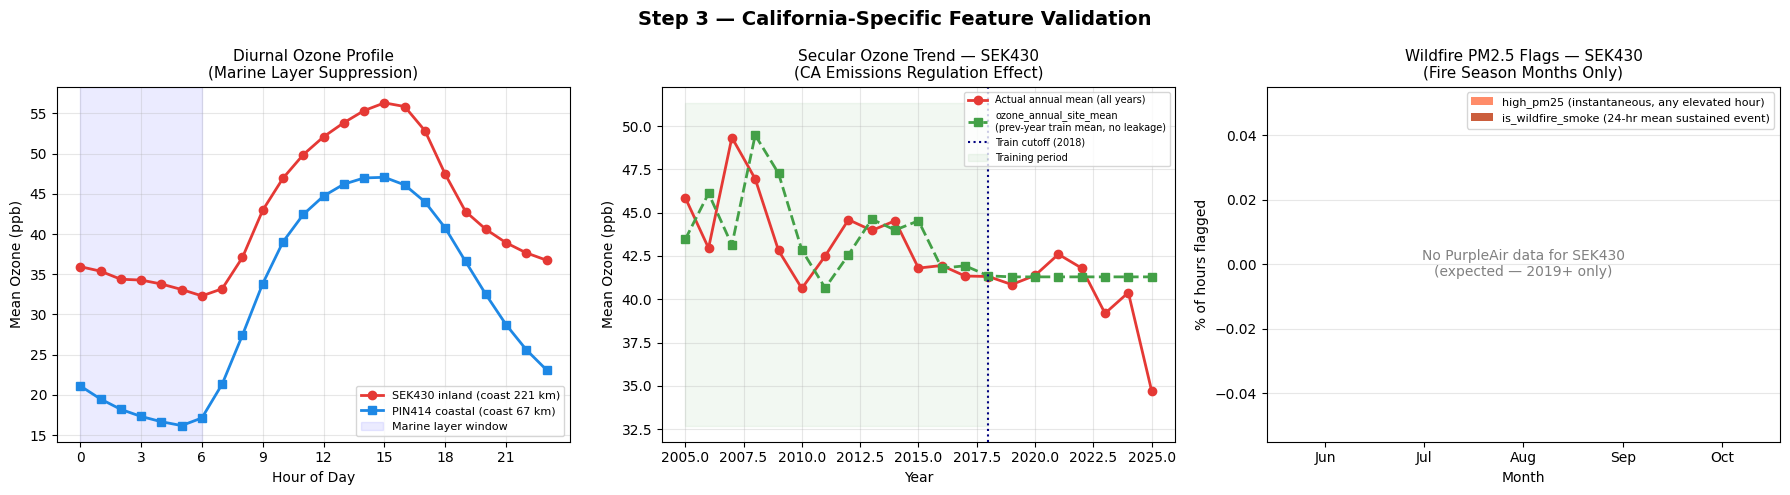


Coastal site classification (50 km threshold):
-------------------------------------------------------
  CAN407                               19.1 km  ✅ COASTAL
  PIN414                               66.8 km     inland
  LPO010                               74.9 km     inland
  SAN405                               75.1 km     inland
  TRI193                              134.9 km     inland
  CON186                              137.5 km     inland
  ABF404                              138.2 km     inland
  SND152                              149.5 km     inland
  JOT403                              179.7 km     inland
  SEK430                              221.2 km     inland
  SEK402                              222.6 km     inland
  LAV410                              225.5 km     inland
  YOS204                              229.7 km     inland
  YOS404                              229.7 km     inland
  DEV412                              336.7 km     inland


In [10]:
# ── Run test builds for PIN414 (coastal) and SEK430 (inland) for comparison ───
print("Building PIN414 (Pinnacles NP, coastal) for comparison...")
builder_pin = SiteHourlyFeatures(
    site_id='PIN414', df_ozone=df_ozone, df_gas=df_gas,
    df_drychem=df_drychem, df_wet=df_wet, df_purpleair=df_purpleair,
    df_fire_daily=df_fire_daily,
    df_site=df_site, config=FE_CONFIG,
)
df_pin = builder_pin.build()

sek_coast = df_test['is_coastal_site'].iloc[0]
pin_coast = df_pin['is_coastal_site'].iloc[0]
print(f"  SEK430 coast dist ~221 km → is_coastal_site = {sek_coast}  (expect 0)")
print(f"  PIN414 coast dist ~64 km  → is_coastal_site = {pin_coast}  (expect 0, just above 50 km)")

# CAN407 if present in data (coast dist ~70 km — also just above 50 km)
# Truly coastal at <50 km would be a site like a Bay Area monitor

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Step 3 — California-Specific Feature Validation', fontsize=14, fontweight='bold')

# ── Plot 1: marine layer diurnal — mean ozone by hour for coastal vs inland ───
if 'hour' in df_test.columns and 'OZONE' in df_test.columns:
    sek_hourly = df_test.groupby('hour')['OZONE'].mean()
    pin_hourly = df_pin.groupby('hour')['OZONE'].mean()
    axes[0].plot(sek_hourly.index, sek_hourly.values, 'o-', color='#E53935',
                 linewidth=2, label=f"SEK430 inland (coast {df_test['COAST_DIST_KM'].iloc[0]:.0f} km)")
    axes[0].plot(pin_hourly.index, pin_hourly.values, 's-', color='#1E88E5',
                 linewidth=2, label=f"PIN414 coastal (coast {df_pin['COAST_DIST_KM'].iloc[0]:.0f} km)")
    axes[0].axvspan(0, 6, alpha=0.08, color='blue', label='Marine layer window')
    axes[0].set_title('Diurnal Ozone Profile\n(Marine Layer Suppression)', fontsize=11)
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Mean Ozone (ppb)')
    axes[0].set_xticks(range(0, 24, 3))
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

# ── Plot 2: secular ozone trend — ozone_annual_site_mean vs actual annual mean ─
if 'year' in df_test.columns and 'ozone_annual_site_mean' in df_test.columns:
    cutoff = FE_CONFIG['train_cutoff_year']
    actual_annual  = df_test.groupby('year')['OZONE'].mean()
    feature_annual = df_test.groupby('year')['ozone_annual_site_mean'].first()
    
    axes[1].plot(actual_annual.index, actual_annual.values, 'o-',
                 color='#E53935', linewidth=2, label='Actual annual mean (all years)')
    axes[1].plot(feature_annual.index, feature_annual.values, 's--',
                 color='#43A047', linewidth=2, label='ozone_annual_site_mean\n(prev-year train mean, no leakage)')
    axes[1].axvline(cutoff, color='navy', linestyle=':', linewidth=1.5, label=f'Train cutoff ({cutoff})')
    axes[1].fill_between(actual_annual.index,
                         actual_annual.min()-2, actual_annual.max()+2,
                         where=[y <= cutoff for y in actual_annual.index],
                         alpha=0.05, color='green', label='Training period')
    axes[1].set_title('Secular Ozone Trend — SEK430\n(CA Emissions Regulation Effect)', fontsize=11)
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Mean Ozone (ppb)')
    axes[1].legend(fontsize=7, loc='upper right')
    axes[1].grid(True, alpha=0.3)

# ── Plot 3: high_pm25 vs is_wildfire_smoke (fire season months only) ──────────
if 'high_pm25' in df_test.columns and 'is_wildfire_smoke' in df_test.columns:
    fire_df = df_test[df_test['is_fire_season'] == 1].copy()
    if not fire_df.empty:
        # Monthly rates during fire season
        hp_monthly  = fire_df.groupby('month')['high_pm25'].mean() * 100
        wf_monthly  = fire_df.groupby('month')['is_wildfire_smoke'].mean() * 100
        x = hp_monthly.index
        w = 0.35
        axes[2].bar(x - w/2, hp_monthly.values, w, color='#FF7043', alpha=0.8,
                    label='high_pm25 (instantaneous, any elevated hour)')
        axes[2].bar(x + w/2, wf_monthly.values, w, color='#BF360C', alpha=0.8,
                    label='is_wildfire_smoke (24-hr mean sustained event)')
        axes[2].set_title('Wildfire PM2.5 Flags — SEK430\n(Fire Season Months Only)', fontsize=11)
        axes[2].set_xlabel('Month')
        axes[2].set_ylabel('% of hours flagged')
        axes[2].set_xticks(list(x))
        axes[2].set_xticklabels(['Jun','Jul','Aug','Sep','Oct'])
        axes[2].legend(fontsize=8)
        axes[2].grid(True, alpha=0.3, axis='y')
        if hp_monthly.empty or hp_monthly.sum() == 0:
            axes[2].text(0.5, 0.5, 'No PurpleAir data for SEK430\n(expected — 2019+ only)',
                        transform=axes[2].transAxes, ha='center', va='center',
                        fontsize=10, color='grey')
    else:
        axes[2].text(0.5, 0.5, 'No fire season data', transform=axes[2].transAxes,
                    ha='center', va='center', fontsize=10, color='grey')

plt.tight_layout()
val_fig = os.path.join(OUTPUT_DIR, 'step3_ca_feature_validation.png')
plt.savefig(val_fig, dpi=150, bbox_inches='tight')
print(f"\nSaved → {val_fig}")
plt.show()

# ── Coastal site summary across all sites ─────────────────────────────────────
print("\nCoastal site classification (50 km threshold):")
print("-" * 55)
if not df_site.empty and 'COAST_DIST_KM' in df_site.columns:
    for _, row in df_site.sort_values('COAST_DIST_KM').iterrows():
        coastal = '✅ COASTAL' if row['COAST_DIST_KM'] < FE_CONFIG['coastal_km'] else '   inland'
        print(f"  {row['SITE_ID']:<8}  {row.get('DISPLAY_NAME',''):<22s}  "
              f"{row['COAST_DIST_KM']:>7.1f} km  {coastal}")


## Section 7: Full California Processing — All Sites via Dask

In [11]:
def build_site_features_wrapper(site_id):
    """
    Wrapper that builds all features for one site.
    Designed to be called in a loop; returns None on failure.
    """
    try:
        builder = SiteHourlyFeatures(
            site_id      = site_id,
            df_ozone     = df_ozone,
            df_gas       = df_gas,
            df_drychem   = df_drychem,
            df_wet       = df_wet,
            df_purpleair = df_purpleair,
            df_fire_daily= df_fire_daily,
            df_site      = df_site,
            config       = FE_CONFIG,
        )
        return builder.build()
    except Exception as e:
        print(f"  ⚠  {site_id}: FAILED — {e}")
        return None

ca_sites = sorted(df_ozone['SITE_ID'].unique())
print(f"Processing {len(ca_sites)} California sites: {ca_sites}")
print("=" * 70)


Processing 12 California sites: ['CAN407', 'CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 'SEK402', 'SEK430', 'SND152', 'YOS204', 'YOS404']


In [12]:
# ── Build per-site DataFrames, then concatenate ───────────────────────────────
site_dfs = []
for sid in ca_sites:
    t0 = datetime.now()
    df_s = build_site_features_wrapper(sid)
    elapsed = (datetime.now() - t0).total_seconds()
    if df_s is not None:
        site_dfs.append(df_s)
        print(f"  ✓  {sid:<8s}  {len(df_s):>9,} rows  "
              f"{len(df_s.columns):>3d} cols  "
              f"NAAQS exceed: {df_s['NAAQS_exceed'].sum():>5,}  "
              f"({elapsed:.1f}s)")
    gc.collect()

print(f"\n✅ All sites processed: {len(site_dfs)}/{len(ca_sites)} succeeded")


  ✓  CAN407      246,689 rows  112 cols  NAAQS exceed:     0  (3.6s)
  ✓  CON186       62,570 rows  107 cols  NAAQS exceed: 14,229  (0.9s)
  ✓  DEV412      153,887 rows  107 cols  NAAQS exceed: 9,047  (2.7s)
  ✓  JOT403      244,399 rows  112 cols  NAAQS exceed: 46,465  (3.5s)
  ✓  LAV410      242,746 rows  112 cols  NAAQS exceed:     0  (3.5s)
  ✓  LPO010       12,496 rows  107 cols  NAAQS exceed:   687  (0.3s)
  ✓  PIN414      250,345 rows  112 cols  NAAQS exceed: 10,086  (3.7s)
  ✓  SEK402       54,390 rows  112 cols  NAAQS exceed: 16,825  (1.1s)
  ✓  SEK430      165,301 rows  107 cols  NAAQS exceed: 32,360  (2.3s)
  ✓  SND152      274,143 rows  112 cols  NAAQS exceed: 12,854  (4.3s)
  ✓  YOS204        8,631 rows  107 cols  NAAQS exceed:   726  (0.3s)
  ✓  YOS404      245,008 rows  112 cols  NAAQS exceed: 21,039  (3.6s)

✅ All sites processed: 12/12 succeeded


In [13]:
# ── Concatenate all sites ─────────────────────────────────────────────────────
print("\nConcatenating all sites...")
df_all = pd.concat(site_dfs, ignore_index=True)
df_all = df_all.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)

print(f"Combined dataset:")
print(f"  Rows    : {len(df_all):,}")
print(f"  Columns : {len(df_all.columns)}")
print(f"  Memory  : {df_all.memory_usage(deep=True).sum()/(1024**2):.1f} MB")
print(f"  Sites   : {df_all['SITE_ID'].nunique()}")
print(f"  Period  : {df_all['DATE_TIME'].min()} → {df_all['DATE_TIME'].max()}")

# Final type cleanup
for col in df_all.select_dtypes('float64').columns:
    df_all[col] = df_all[col].astype('float32')
for col in df_all.select_dtypes('int64').columns:
    df_all[col] = df_all[col].astype('int32')



Concatenating all sites...
Combined dataset:
  Rows    : 1,960,605
  Columns : 112
  Memory  : 852.6 MB
  Sites   : 12
  Period  : 1990-01-01 00:00:00 → 2025-05-31 23:00:00


## Section 8: NAAQS Exceedance Analysis by Site & Season

In [14]:
print("NAAQS Exceedance Summary (8-hr O3 > 70 ppb)")
print("=" * 70)

exc = df_all.groupby('SITE_ID').agg(
    total_hours  = ('OZONE',         'count'),
    naaqs_hours  = ('NAAQS_exceed',  'sum'),
    mean_ozone   = ('OZONE',         'mean'),
    p90_ozone    = ('OZONE',         lambda x: x.quantile(0.90)),
    mean_8hr_max = ('OZONE_8hr_max', 'mean'),
).round(2)
exc['exceed_pct'] = (exc['naaqs_hours'] / exc['total_hours'] * 100).round(2)

# ── Join site metadata from df_site (covers all discovered sites) ──────────────
if not df_site.empty:
    _site_cols = [c for c in ['SITE_ID', 'ELEVATION_M', 'COAST_DIST_KM',
                               'MARINE_INFLUENCE', 'DISPLAY_NAME', 'REGION']
                  if c in df_site.columns]
    exc = exc.reset_index().merge(
        df_site[_site_cols].drop_duplicates('SITE_ID'),
        on='SITE_ID', how='left'
    ).set_index('SITE_ID')
else:
    exc = exc.reset_index().set_index('SITE_ID')

_show = [c for c in ['total_hours', 'naaqs_hours', 'exceed_pct', 'mean_ozone',
                      'p90_ozone', 'mean_8hr_max', 'ELEVATION_M',
                      'COAST_DIST_KM', 'MARINE_INFLUENCE'] if c in exc.columns]
print(exc[_show].sort_values('exceed_pct', ascending=False).to_string())


NAAQS Exceedance Summary (8-hr O3 > 70 ppb)
         total_hours  naaqs_hours  exceed_pct  mean_ozone  p90_ozone  mean_8hr_max  ELEVATION_M  COAST_DIST_KM MARINE_INFLUENCE
SITE_ID                                                                                                                        
SEK402         54390        16825     30.9300     49.9200    80.0000       58.4700    1225.0000       222.6000           INLAND
CON186         62570        14229     22.7400     50.3400    73.0000       58.4500    1718.0000       137.5000       TRANSITION
SEK430        165301        32360     19.5800     42.4800    70.0000       50.6000     510.0000       221.2000           INLAND
JOT403        244399        46465     19.0100     52.0300    70.0000       57.2900    1244.0000       179.7000       TRANSITION
YOS404        245008        21039      8.5900     46.7100    63.0000       51.1500    1605.0000       229.7000           INLAND
YOS204          8631          726      8.4100     48.3000   

Saved → C:\MATH699P\Data\processed_data\california\features_parquet\ca_naaqs_exceedance.png


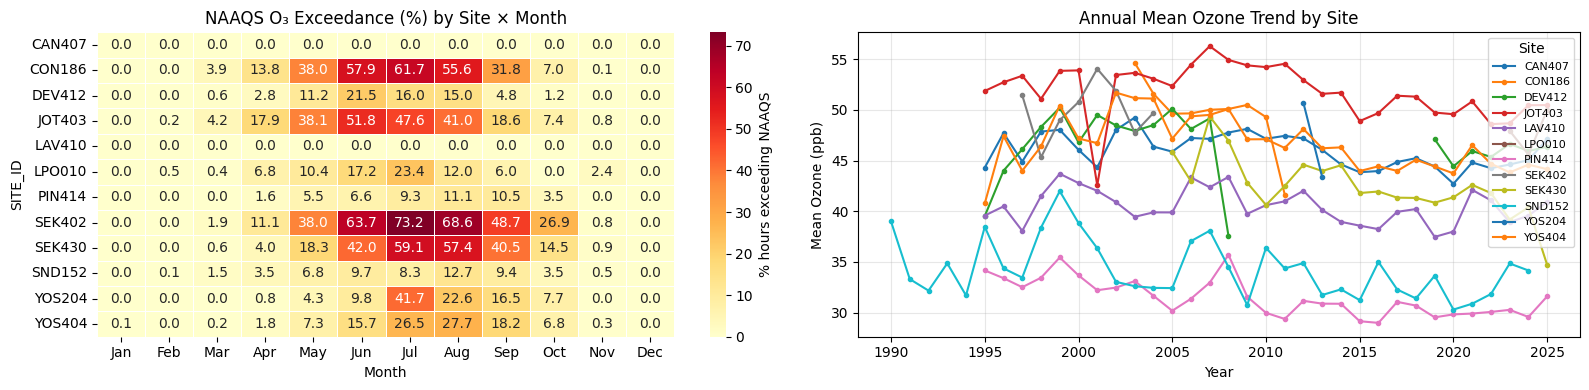

In [15]:
# ── Seasonal × site NAAQS exceedance heat-map ─────────────────────────────────
pivot_exc = df_all.groupby(['SITE_ID', 'month'])['NAAQS_exceed'].mean() * 100
pivot_exc = pivot_exc.unstack('month').fillna(0)
pivot_exc.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(pivot_exc, ax=axes[0], cmap='YlOrRd', fmt='.1f', annot=True,
            linewidths=0.5, cbar_kws={'label': '% hours exceeding NAAQS'})
axes[0].set_title('NAAQS O₃ Exceedance (%) by Site × Month')
axes[0].set_xlabel('Month')

# Annual mean ozone trend per site
annual = df_all.groupby(['SITE_ID', 'year'])['OZONE'].mean().unstack('SITE_ID')
annual.plot(ax=axes[1], marker='o', markersize=3, linewidth=1.5)
axes[1].set_title('Annual Mean Ozone Trend by Site')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Ozone (ppb)')
axes[1].legend(title='Site', fontsize=8, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'ca_naaqs_exceedance.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved → {fig_path}")
plt.show()


## Section 9: Feature Audit — Correlation, Variance, Completeness

In [16]:
# ── Define final feature columns (exclude IDs and raw backups) ────────────────
EXCLUDE_FROM_FEATURES = [
    'SITE_ID', 'DATE_TIME', 'OZONE',          # IDs + target
    'QA_CODE', 'hour_category', 'season',     # categorical strings (already encoded)
    'LAND_USE', 'TERRAIN', 'STATE',           # string columns
]
# Also exclude *_raw backup columns from features
raw_backup_cols = [c for c in df_all.columns if c.endswith('_raw')]
EXCLUDE_FROM_FEATURES += raw_backup_cols

numeric_dtypes = ['int8','int16','int32','int64','float16','float32','float64']
FEATURE_COLS = [c for c in df_all.columns
                if str(df_all[c].dtype) in numeric_dtypes
                and c not in EXCLUDE_FROM_FEATURES]

print(f"Feature columns identified: {len(FEATURE_COLS)}")
print(f"Excluded (IDs/target/raw) : {len(EXCLUDE_FROM_FEATURES)}")
print(f"Total DataFrame columns   : {len(df_all.columns)}")


Feature columns identified: 107
Excluded (IDs/target/raw) : 10
Total DataFrame columns   : 112


In [17]:
# ── Variance audit — drop near-zero variance features ────────────────────────
feature_stats = pd.DataFrame({
    'variance'   : df_all[FEATURE_COLS].var(),
    'missing_pct': df_all[FEATURE_COLS].isnull().mean() * 100,
    'nunique'    : df_all[FEATURE_COLS].nunique(),
}).sort_values('variance')

LOW_VAR_THRESHOLD  = 1e-6
HIGH_MISS_THRESHOLD = 80.0  # drop if >80% missing

low_var_cols  = feature_stats[feature_stats['variance'] < LOW_VAR_THRESHOLD].index.tolist()
high_miss_cols = feature_stats[feature_stats['missing_pct'] > HIGH_MISS_THRESHOLD].index.tolist()
drop_cols = list(set(low_var_cols + high_miss_cols))

print(f"Low-variance features  (<{LOW_VAR_THRESHOLD})   : {len(low_var_cols)}")
if low_var_cols:
    print(f"  {low_var_cols}")
print(f"High-missing features  (>{HIGH_MISS_THRESHOLD}%) : {len(high_miss_cols)}")
if high_miss_cols:
    print(f"  {high_miss_cols}")
print(f"Total features to drop  : {len(drop_cols)}")

FEATURE_COLS_FINAL = [c for c in FEATURE_COLS if c not in drop_cols]
print(f"\nFinal feature count: {len(FEATURE_COLS_FINAL)}")


Low-variance features  (<1e-06)   : 2
  ['is_wildfire_smoke', 'high_pm25']
High-missing features  (>80.0%) : 4
  ['PM25_EPA', 'PM25_rmean_24', 'PM25_rmean_72', 'PM25_rmax_72']
Total features to drop  : 6

Final feature count: 101



Top 30 features by |correlation| with OZONE:
-------------------------------------------------------
OZONE_rmean_3            0.9763
OZONE_rmax_3             0.9695
OZONE_lag_1              0.9670
OZONE_rmin_3             0.9590
OZONE_rmean_6            0.9154
OZONE_lag_2              0.9109
OZONE_rmax_6             0.8988
OZONE_rmin_6             0.8674
OZONE_lag_3              0.8491
OZONE_8hr_max            0.8467
OZONE_rmean_24           0.7965
OZONE_rmean_12           0.7904
OZONE_lag_24             0.7725
OZONE_diurnal_anomaly    0.7680
OZONE_rmax_12            0.7507
OZONE_rmin_12            0.7159
OZONE_rmax_24            0.6995
OZONE_rmean_168          0.6953
OZONE_rmin_24            0.6925
OZONE_above_median       0.6718
OZONE_lag_48             0.6626
OZONE_lag_6              0.6522
OZONE_above_p75          0.6486
OZONE_pct_rank_rolling   0.6066
OZONE_rmin_168           0.5632
OZONE_rmax_168           0.5477
OZONE_diff_168           0.5046
OZONE_lag_168            0.4967
oz

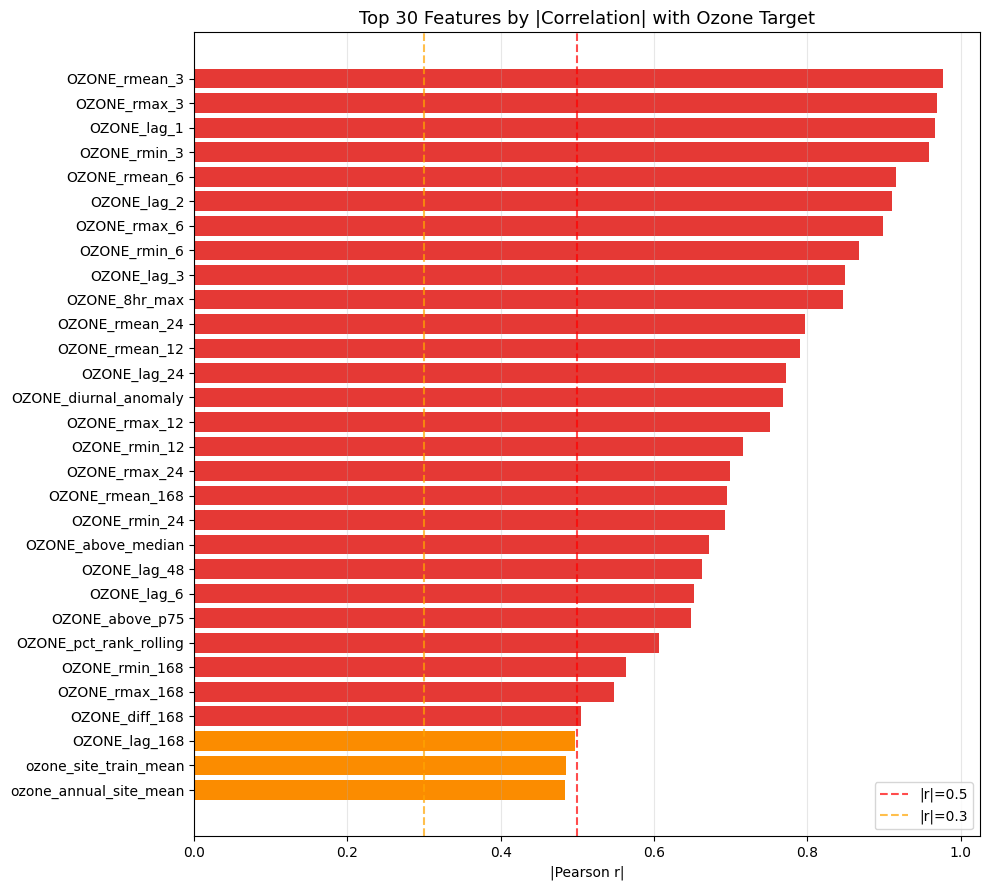

In [18]:
# ── Top correlations with OZONE target ───────────────────────────────────────
sample = df_all[FEATURE_COLS_FINAL + ['OZONE']].dropna().sample(
    min(50_000, len(df_all)), random_state=42
)
corr_with_target = (sample.corr()['OZONE']
                         .drop('OZONE')
                         .abs()
                         .sort_values(ascending=False))

print("\nTop 30 features by |correlation| with OZONE:")
print("-" * 55)
print(corr_with_target.head(30).round(4).to_string())

# ── Correlation bar plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
top30 = corr_with_target.head(30)
colors = ['#E53935' if v > 0.5 else '#FB8C00' if v > 0.3 else '#43A047'
          for v in top30.values]
ax.barh(top30.index[::-1], top30.values[::-1], color=colors[::-1])
ax.axvline(0.5, color='red',    linestyle='--', alpha=0.7, label='|r|=0.5')
ax.axvline(0.3, color='orange', linestyle='--', alpha=0.7, label='|r|=0.3')
ax.set_title('Top 30 Features by |Correlation| with Ozone Target', fontsize=13)
ax.set_xlabel('|Pearson r|')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
corr_fig = os.path.join(OUTPUT_DIR, 'feature_correlation.png')
plt.savefig(corr_fig, dpi=150, bbox_inches='tight')
print(f"\nSaved → {corr_fig}")
plt.show()


## Section 10: Save Features to Parquet

In [19]:
# ── Columns to save ───────────────────────────────────────────────────────────
SAVE_COLS = ['SITE_ID', 'DATE_TIME', 'OZONE'] + FEATURE_COLS_FINAL
SAVE_COLS = [c for c in SAVE_COLS if c in df_all.columns]

df_save = df_all[SAVE_COLS].copy()

# ── Convert to Dask and write partitioned Parquet ─────────────────────────────
# Partition by SITE_ID so each downstream site-level read is one file
n_parts = max(1, len(ca_sites))
ddf_save = dd.from_pandas(df_save, npartitions=n_parts)

output_path = os.path.join(OUTPUT_DIR, 'features_engineered')
print(f"Writing to: {output_path}")
print(f"Partitions : {n_parts}  ({len(df_save):,} rows total)")

# Flat layout: one Parquet file per site (npartitions = n_sites above).
# No hive partitioning — dask/pyarrow version skew causes KeyError on
# SITE_ID partition-key reconstruction when reading with dd.read_parquet.
# Per-site filtering after loading: ddf[ddf['SITE_ID'] == sid].compute()
with ProgressBar():
    ddf_save.to_parquet(
        output_path,
        engine='pyarrow',
        compression='snappy',
        write_index=False,
    )

print("\n✅ Parquet write complete.")

Writing to: C:\MATH699P\Data\processed_data\california\features_parquet\features_engineered
Partitions : 12  (1,960,605 rows total)
[########################################] | 100% Completed | 2.05 sms

✅ Parquet write complete.


## Section 11: Save Feature Metadata & Preprocessing Artefacts

In [20]:
# ── Per-site year coverage (important: some sites start later than others) ─────
site_year_ranges = {}
for sid, grp in df_all.groupby('SITE_ID'):
    yrs = grp['year'].dropna()
    if not yrs.empty:
        site_year_ranges[sid] = {'min_year': int(yrs.min()), 'max_year': int(yrs.max()),
                                 'n_years': int(yrs.nunique())}

print("Per-site year coverage:")
for sid, yr in sorted(site_year_ranges.items()):
    print(f"  {sid}  {yr['min_year']}–{yr['max_year']}  ({yr['n_years']} years)")

# ── Save feature list and preprocessing metadata ──────────────────────────────
preprocessing_meta = {
    'feature_cols'       : FEATURE_COLS_FINAL,
    'target_col'         : 'OZONE',
    'id_cols'            : ['SITE_ID', 'DATE_TIME'],
    'n_features'         : len(FEATURE_COLS_FINAL),
    'ca_sites'           : ca_sites,
    'n_sites'            : len(ca_sites),
    'site_year_ranges'   : site_year_ranges,
    'fe_config'          : FE_CONFIG,
    'drop_cols'          : drop_cols,
    'raw_backup_cols'    : raw_backup_cols,
    'generated'          : datetime.now().isoformat(),
    'naaqs_threshold'    : FE_CONFIG['naaqs_threshold'],
    'ozone_date_range'   : (str(df_all['DATE_TIME'].min()),
                            str(df_all['DATE_TIME'].max())),
    'total_rows'         : len(df_all),
}

pkl_path = os.path.join(OUTPUT_DIR, 'ca_feature_metadata.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump(preprocessing_meta, f)
print(f"\nSaved preprocessing metadata → {pkl_path}")

# ── Human-readable feature list ───────────────────────────────────────────────
txt_path = os.path.join(OUTPUT_DIR, 'ca_feature_list.txt')
with open(txt_path, 'w') as f:
    f.write(f"California CASTNET — Feature List\n")
    f.write(f"Generated : {datetime.now():%Y-%m-%d %H:%M}\n")
    f.write(f"Sites     : {ca_sites}\n")
    f.write(f"Total     : {len(FEATURE_COLS_FINAL)} features\n")
    f.write("=" * 60 + "\n\n")
    groups = {
        'Temporal'        : [c for c in FEATURE_COLS_FINAL if any(x in c for x in
                             ['year','month','day','hour','week','quarter',
                              'season','is_weekend','is_fire','is_summer',
                              'is_night','is_peak','year_trend','sin','cos'])],
        'Site static'     : [c for c in FEATURE_COLS_FINAL if any(x in c for x in
                             ['ELEVATION','COAST','MARINE','TERRAIN','LAT','LON'])],
        'Ozone timeseries': [c for c in FEATURE_COLS_FINAL if 'OZONE' in c or 'NAAQS' in c],
        'Hourly gas'      : [c for c in FEATURE_COLS_FINAL if any(x in c for x in
                             ['NO','NOY','NOX','HNO3','SO2_GA','CO','TEMP_2M',
                              'TEMP_23M','NOx','NOy_minus','is_hot'])],
        'Dry chemistry'   : [c for c in FEATURE_COLS_FINAL if c.startswith('DC_')],
        'Wet chemistry'   : [c for c in FEATURE_COLS_FINAL if c.startswith('WET_')
                             or c == 'is_post_rain'],
        'PurpleAir PM2.5' : [c for c in FEATURE_COLS_FINAL if 'PM25' in c
                             or 'smoke' in c or 'wildfire' in c],
    }
    for grp, cols in groups.items():
        f.write(f"\n{grp} ({len(cols)})\n")
        for c in cols:
            f.write(f"  {c}\n")

print(f"Saved feature list       → {txt_path}")


Per-site year coverage:
  CAN407  1995–2025  (31 years)
  CON186  2003–2011  (9 years)
  DEV412  1995–2025  (21 years)
  JOT403  1995–2025  (31 years)
  LAV410  1995–2025  (31 years)
  LPO010  2023–2025  (3 years)
  PIN414  1995–2025  (31 years)
  SEK402  1997–2004  (8 years)
  SEK430  2005–2025  (21 years)
  SND152  1990–2024  (35 years)
  YOS204  2012–2013  (2 years)
  YOS404  1995–2025  (31 years)

Saved preprocessing metadata → C:\MATH699P\Data\processed_data\california\features_parquet\ca_feature_metadata.pkl
Saved feature list       → C:\MATH699P\Data\processed_data\california\features_parquet\ca_feature_list.txt


## Section 12: Verification & Handoff Summary

In [21]:
print("=" * 80)
print("VERIFICATION — Reading back from Parquet")
print("=" * 80)

ddf_verify = dd.read_parquet(output_path)
print(f"Parquet columns  : {len(ddf_verify.columns)}")
print(f"Parquet rows     : {len(ddf_verify):,}")
print(f"\nFirst 5 column names : {list(ddf_verify.columns[:5])}")
print(f"Sample row:")
print(ddf_verify.head(2).T.to_string())


VERIFICATION — Reading back from Parquet
Parquet columns  : 104
Parquet rows     : 3,921,210

First 5 column names : ['DATE_TIME', 'OZONE', 'YEAR', 'MONTH', 'DC_TSO4']
Sample row:
                                              0                    1
DATE_TIME                   1995-01-01 00:00:00  1995-01-01 01:00:00
OZONE                                   41.0000              41.0000
YEAR                                       1995                 1995
MONTH                                         1                    1
DC_TSO4                                  0.5359               0.5359
DC_TNO3                                  0.2036               0.2036
DC_TNH4                                  0.1961               0.1961
DC_CA                                    0.2109               0.2109
DC_MG                                    0.0289               0.0289
DC_NA                                    0.0486               0.0486
DC_K                                     0.0423              

In [22]:
print("=" * 80)
print("HANDOFF SUMMARY — Outputs ready for model_preparation.ipynb")
print("=" * 80)

outputs = {
    output_path                                          : 'Parquet feature store (partitioned)',
    pkl_path                                             : 'Preprocessing metadata (pickle)',
    txt_path                                             : 'Human-readable feature list',
    os.path.join(OUTPUT_DIR, 'ca_naaqs_exceedance.png') : 'NAAQS exceedance chart',
    os.path.join(OUTPUT_DIR, 'feature_correlation.png') : 'Feature correlation chart',
}

for path, desc in outputs.items():
    exists = '✅' if os.path.exists(path) else '❌'
    print(f"  {exists}  {os.path.basename(path):<45s}  {desc}")

print(f"\n  Total features     : {len(FEATURE_COLS_FINAL)}")
print(f"  Target column      : OZONE (ppb)")
print(f"  NAAQS exceed col   : NAAQS_exceed (binary, 8-hr max > 70 ppb)")
print(f"  Sites processed    : {len(ca_sites)}")
print()

# Per-site row counts and year ranges
print("  Per-site summary:")
print(f"  {'SITE_ID':<8}  {'Rows':>9}  {'Min Year':>9}  {'Max Year':>9}  {'N Years':>8}")
print("  " + "-" * 50)
for sid in sorted(ca_sites):
    site_rows = len(df_all[df_all['SITE_ID'] == sid])
    yr_info = site_year_ranges.get(sid, {})
    print(f"  {sid:<8}  {site_rows:>9,}  "
          f"{yr_info.get('min_year', '—'):>9}  "
          f"{yr_info.get('max_year', '—'):>9}  "
          f"{yr_info.get('n_years', '—'):>8}")

print(f"\nNext: model_preparation.ipynb")
print(f"  - Load features from : {output_path}")
print(f"  - Load metadata from : {pkl_path}")
print(f"  - Temporal split     : train ≤2018 | val 2019–2020 | test 2021–2025")
print(f"  - Sites with shorter records (SND152, ABF404, SAN405, CAN407)")
print(f"    may need site-stratified evaluation")


HANDOFF SUMMARY — Outputs ready for model_preparation.ipynb
  ✅  features_engineered                            Parquet feature store (partitioned)
  ✅  ca_feature_metadata.pkl                        Preprocessing metadata (pickle)
  ✅  ca_feature_list.txt                            Human-readable feature list
  ✅  ca_naaqs_exceedance.png                        NAAQS exceedance chart
  ✅  feature_correlation.png                        Feature correlation chart

  Total features     : 101
  Target column      : OZONE (ppb)
  NAAQS exceed col   : NAAQS_exceed (binary, 8-hr max > 70 ppb)
  Sites processed    : 12

  Per-site summary:
  SITE_ID        Rows   Min Year   Max Year   N Years
  --------------------------------------------------
  CAN407      246,689       1995       2025        31
  CON186       62,570       2003       2011         9
  DEV412      153,887       1995       2025        21
  JOT403      244,399       1995       2025        31
  LAV410      242,746       1995      

In [23]:
# ── DASHBOARD EXPORT ──────────────────────────────────────────
import json
from pathlib import Path

# DASH_DIR is already defined in the config cell (cell 4) — reuse it here
DASH_DIR = Path(DASH_DIR)
DASH_DIR.mkdir(exist_ok=True)

status = {}
try:
    with open(DASH_DIR / "pipeline_status.json") as f:
        status = json.load(f)
except FileNotFoundError:
    pass
status["feature_engineering"] = {
    "status"    : "complete",
    "timestamp" : pd.Timestamp.now().isoformat(),
    "n_features": len(FEATURE_COLS_FINAL),
    "n_sites"   : df_ozone['SITE_ID'].nunique(),
    "fire_features_present": any(
        c.startswith('fire_') for c in FEATURE_COLS_FINAL
    ),
}
with open(DASH_DIR / "pipeline_status.json", "w") as f:
    json.dump(status, f, indent=2)

print(f"✅ Feature engineering status exported ({len(FEATURE_COLS_FINAL)} features)")

✅ Feature engineering status exported (101 features)
